# **Aplicaciones de Ciencia de Datos**
## **Taller Práctico - Graph Representation Learning.**



In this notebook we will accomplish an introduction to Graph Representation Learning (GRL) with Random Walks (RWs).

First, some materials are available for introducing NetworkX, a python library for graphs [NetworkX](https://networkx.org/documentation/stable/). Later, we present a toy example for the computation of interesting metrics on a small graph. Finally, we will tackle the GRL of this graph using RWs.


# Setup

Check if the installation was successfull:

In [2]:
import numpy, scipy, networkx, gensim
import pandas as pd
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print('Dependencias cargadas correctamente y configuradas usando uv.')


Dependencias cargadas correctamente y configuradas usando uv.


After a visual inspection of the embeddings. What do you think?

Actually, there would be two ways to evaluate the quality of the embeddings, both ways depending on the final task to be accomplished:
1. A direct evaluation based on some metric. For example, we could check if the distance of the nodes in the original space (the graph) is similar to their distance in the embedding space.
2. An indirect evaluation based on the quality of the results of downstream analyses. For example, if the embeddings are to be used as input for a classification or clustering algorithm, the quality of the results obtained by these downstream tools would indirectly depend on the quality of the embeddings.

## TASKS FOR CLASS




### COMMUNITY DETECTION AND VISUALIZATION



Use your preferred R or Python libraries to perform a community detection on the karate-club network using clustering algorithms starting from the RW embeddings. The following will be assessed:
- Test different parameter configuration for the RW embedding (number of walks, length, p and q for the 2nd order RW, etc).
- The use of different clustering algorithms.
- The use of different distance measures.
- The visualization of the resulting groups to justify the obtained communities. You can explore the use of t-SNE, PCA or UMAP for projecting the embeddings into a 2-D plot.







---



# Assignment

You are asked to run different Graph Representation Learning (GRL) algorithms based on Random Walks (RWs) for obtaining embeddings of a biomedical network and perform further downstream ML analyses on the obtained embeddings using clustering and classification algorithms.

## Description of the network

This assignment is based on the code by the SNAP Group at Stanford:
https://snap.stanford.edu/deepnetbio-ismb/ipynb/Human%2BDisease%2BNetwork.html

Please, have a look at the link above to understand the problem. Briefly, the Human disease network is a network, in which **each node represents a different disease** and two diseases are connected to each other if they share at least one gene in which mutations are associated with both diseases. This network is undirected and unweighted.

The network is described in [Goh et al., The Human Disease Network, PNAS 2007.](http://www.pnas.org/content/104/21/8685)

There are two files that we will be using:
-    The edge list defining the network. This file contains pairs of connected nodes, each node represented by a numeric ID. Check it out at: https://snap.stanford.edu/deepnetbio-ismb/ipynb/diseasome.edgelist

-    The disease labels. Each disease is associated to a **name** and a **disease category** (e.g. cancer, cardiovascular, bone, etc). https://snap.stanford.edu/deepnetbio-ismb/ipynb/disease.labels


The following code downloads the dataset and creates the networkx graph with the network. The disease name and disease category are saved as properties `label` and `disease_class` for each node.

Loaded graph with 516 nodes and 1188 edges.


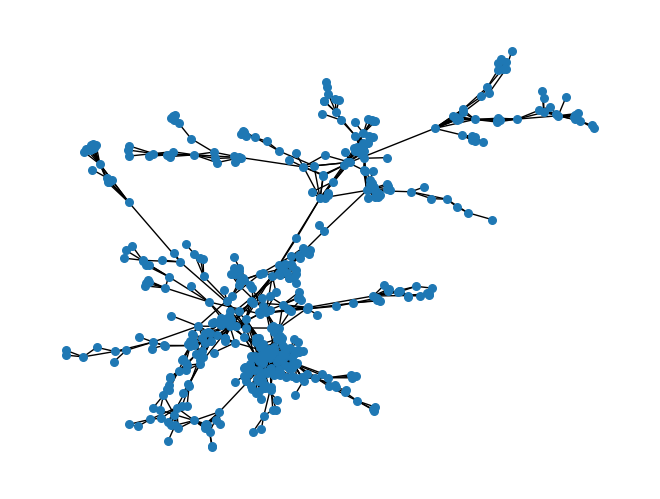

Loaded node labels for 516 nodes.
{'label': 'Osteoporosis', 'disease_class': 'Bone'}
{'label': 'Carpal tunnel syndrome, familial', 'disease_class': 'Unclassified'}


In [17]:
import os
import urllib.request
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from node2vec import Node2Vec
from sklearn.manifold import TSNE

# 1. Download the dataset
network_url = "https://snap.stanford.edu/deepnetbio-ismb/ipynb/diseasome.edgelist"
labels_url = "https://snap.stanford.edu/deepnetbio-ismb/ipynb/disease.labels"
network_file = "diseasome_edgelist.csv"
labels_file = "disease_labels.csv"

for url, file in [(network_url, network_file), (labels_url, labels_file)]:
    if not os.path.exists(file):
        print(f"Downloading {file}...")
        urllib.request.urlretrieve(url, file)

# 2. Load into a NetworkX graph
G = nx.read_edgelist(
    network_file,
    delimiter=' ',
    create_using=nx.Graph(),
    nodetype=str
)

print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

nx.draw(G, with_labels = False, node_size= 30)
plt.show()

# 3. Load labels
df_labels = pd.read_csv(labels_file, sep=',', header=0, names=["DiseaseID", "Label", "DiseaseClass"], dtype={"DiseaseID":"str", "Label":"str", "DiseaseClass":"str"})
label_dict = df_labels.set_index("DiseaseID").to_dict(orient="index")


# 4. Add labels to graph nodes
for node in G.nodes():
    if node in label_dict:
        G.nodes[node]["label"] = label_dict[node]["Label"]
        G.nodes[node]["disease_class"] = label_dict[node]["DiseaseClass"]
    else:
        G.nodes[node]["label"] = "Unknown"
        G.nodes[node]["disease_class"] = "Unknown"

print(f"Loaded node labels for {G.number_of_nodes()} nodes.")

# Quick check that the labels have been loaded to the nodes by printing the first and last node's labels
print(G.nodes['222'])
print(G.nodes['1081'])


# TASK 1: GRL

Compute the node embeddings for the disease network using RWs following the methodologies proposed in the previous code. The following aspects will be evaluated:
- Use of RWs and 2nd order RWs.
- Experimentation for the parameter setting (walk length, number of walks, size of the embedding, p, q, etc).
- The visualization of the resulting embeddings for visual inspection prior to other downstream ML tasks. You can explore the use of t-SNE, PCA or UMAP for projecting the embeddings into a 2-D plot.


### 1. Importar librerías necesarias

Asegúrate de ejecutar esto primero. Si decides usar UMAP (muy recomendado por su velocidad y calidad), puede que necesites instalarlo previamente con `!pip install umap-learn` (ya está instalado en el entorno de `uv`).

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

### 2. Función para experimentar con los Random Walks

Esta función permite generar distintos modelos variando los parámetros fácilmente para comparar los Random Walks de primer orden y los de segundo orden:

* Si `p=1` y `q=1`, se tiene un Random Walk clásico (similar a DeepWalk).
* Si se modifican `p` (probabilidad de retorno) y `q` (probabilidad de alejarse), se obtiene un Random Walk de 2º orden (Node2Vec).

In [19]:
def entrenar_node2vec(grafo, dimensions=64, walk_length=30, num_walks=200, p=1.0, q=1.0):
    """
    Entrena un modelo Node2Vec y devuelve los embeddings.
    """
    print(f"Entrenando con: dim={dimensions}, walk_length={walk_length}, num_walks={num_walks}, p={p}, q={q}")
    
    # Inicializar generador de Random Walks
    n2v = Node2Vec(grafo, dimensions=dimensions, walk_length=walk_length, 
                   num_walks=num_walks, p=p, q=q, workers=4, quiet=True)
    
    # Entrenar el modelo Word2Vec subyacente
    # window es el tamaño de contexto. min_count=1 asegura que no ignoramos nodos.
    modelo = n2v.fit(window=10, min_count=1, batch_words=4)
    
    return modelo

### 3. Función de Visualización (PCA, t-SNE, UMAP)

Para evaluar visualmente si los *embeddings* tienen sentido, proyectamos las 64 dimensiones a solo 2 utilizando distintos métodos de reducción de dimensionalidad.

In [20]:
def visualizar_embeddings(modelo, grafo, etiquetas_dict=None, metodo='tsne', titulo="Visualización"):
    """
    Reduce la dimensionalidad y grafica los nodos.
    etiquetas_dict: Diccionario opcional {id_nodo: 'categoria'} para colorear.
    """
    # Extraer vectores de todos los nodos
    nodos = [str(n) for n in grafo.nodes()]
    vectores = np.array([modelo.wv[n] for n in nodos])
    
    # Selección del algoritmo de reducción
    if metodo == 'pca':
        reductor = PCA(n_components=2)
    elif metodo == 'tsne':
        reductor = TSNE(n_components=2, perplexity=30, random_state=42)
    elif metodo == 'umap':
        reductor = umap.UMAP(n_components=2, random_state=42)
    else:
        raise ValueError("Método no soportado. Usa 'pca', 'tsne' o 'umap'.")
        
    embeddings_2d = reductor.fit_transform(vectores)
    
    # Preparar colores si hay etiquetas
    colores = 'blue' # Color por defecto
    if etiquetas_dict:
        # Extraer etiquetas en el mismo orden que los nodos
        lista_etiquetas = [etiquetas_dict.get(n, "Desconocido") for n in nodos]
        # Crear un mapeo de categoría a un número para colorear
        categorias_unicas = list(set(lista_etiquetas))
        mapa_colores = {cat: i for i, cat in enumerate(categorias_unicas)}
        colores = [mapa_colores[cat] for cat in lista_etiquetas]

    # Graficar
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colores, cmap='tab10', alpha=0.7, s=30)
    
    # Añadir leyenda si tenemos etiquetas
    if etiquetas_dict:
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(mapa_colores[cat])), markersize=8) for cat in categorias_unicas]
        plt.legend(handles, categorias_unicas, title="Categorías", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(f"{titulo} ({metodo.upper()})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### 4. Ejecución y Experimentación

Realizaremos 3 configuraciones distintas de Random Walks para obtener diferentes representaciones y evaluarlas visualmente:

1. **Experimento 1: Random Walk Clásico (p=1, q=1)**, similar a DeepWalk.
2. **Experimento 2: 2nd Order RW con sesgo hacia DFS (q=0.5, p=1.0)**, que prioriza explorar nodos lejanos (homofilia).
3. **Experimento 3: 2nd Order RW con sesgo hacia BFS (q=2.0, p=0.5)**, que prioriza explorar nodos locales (equivalencia estructural).

Entrenando con: dim=64, walk_length=30, num_walks=200, p=1.0, q=1.0


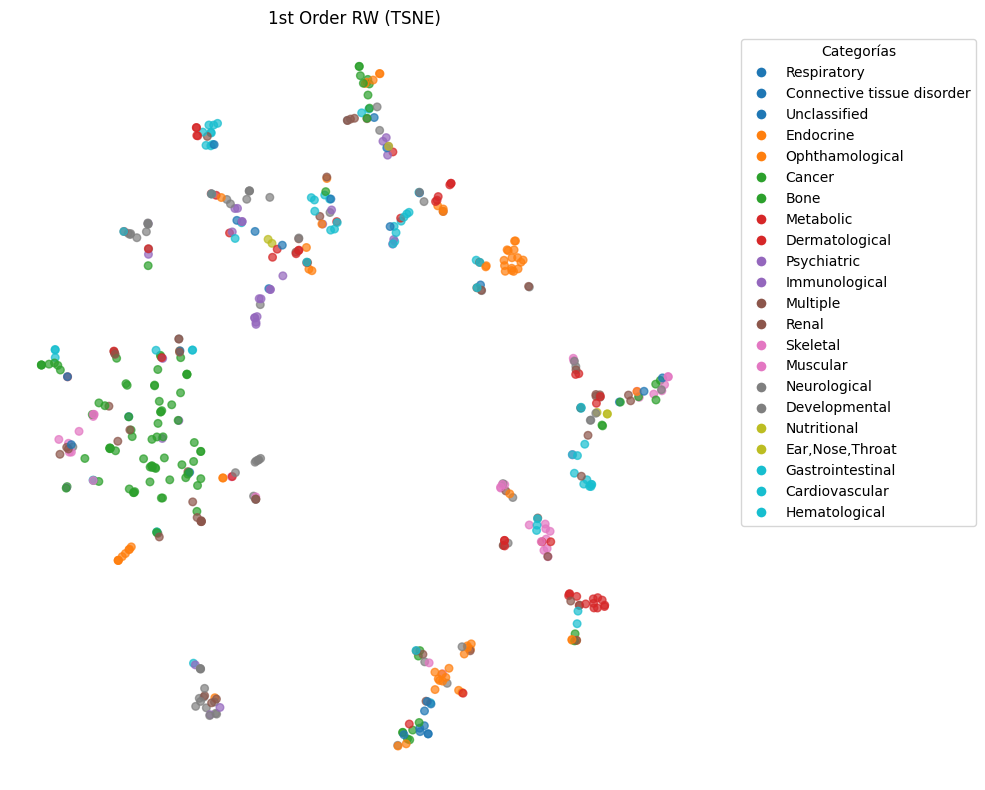

Entrenando con: dim=64, walk_length=30, num_walks=200, p=1.0, q=0.5


c:\Users\pacoc\Desktop\Paco\Master\2 Cuatri\Aplicaciones de Ciencia de Datos\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


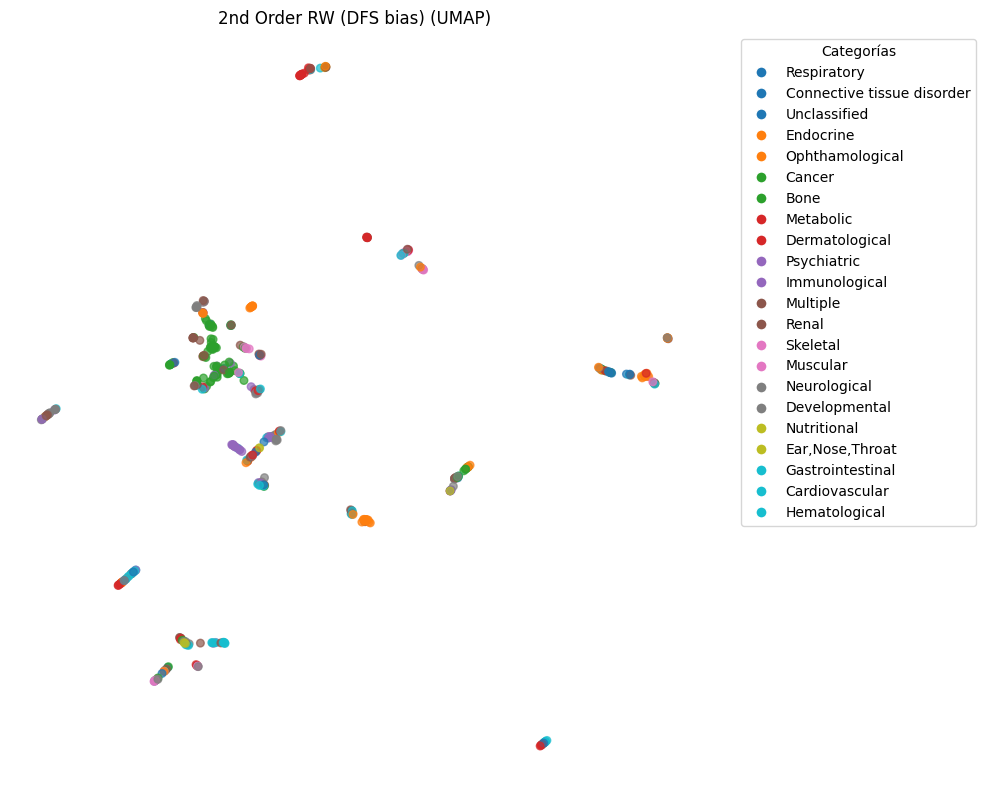

Entrenando con: dim=64, walk_length=30, num_walks=200, p=0.5, q=2.0


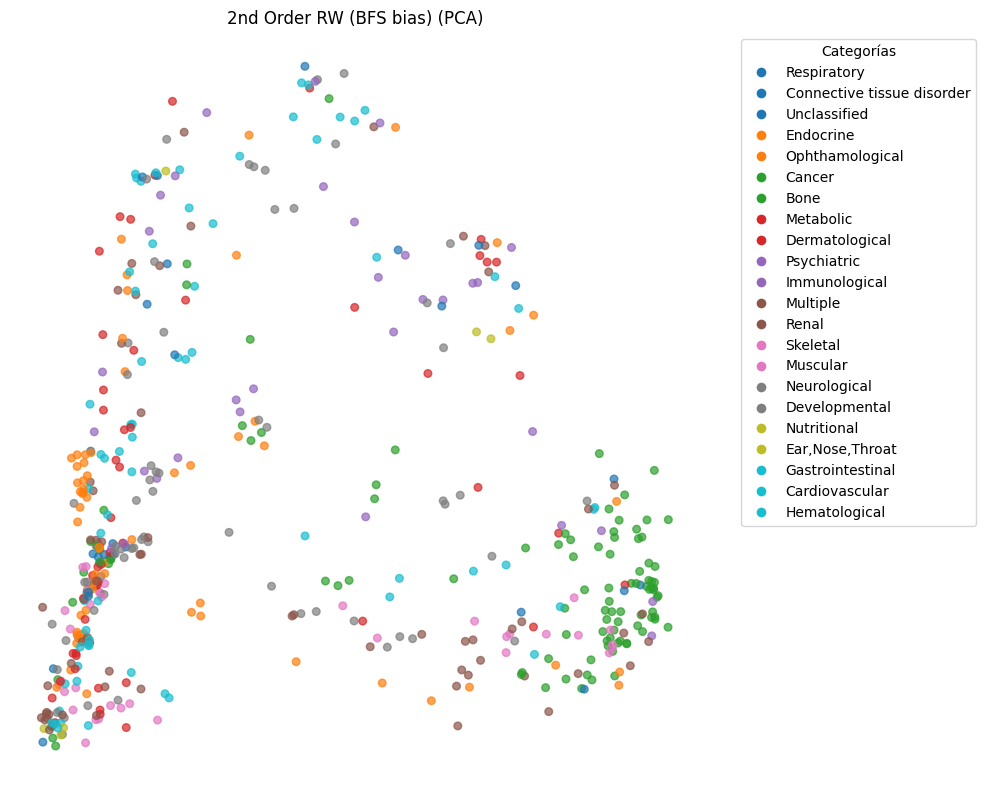

In [21]:
# Mapeo de identificadores de nodo a su categoría de enfermedad (DiseaseClass)
disease_labels = {node: label_dict.get(node, {}).get("DiseaseClass", "Unknown") for node in G.nodes()}

# Experimento 1: Random Walk Clásico (p=1, q=1)
modelo_rw = entrenar_node2vec(G, p=1.0, q=1.0)
visualizar_embeddings(modelo_rw, G, etiquetas_dict=disease_labels, metodo='tsne', titulo="1st Order RW")

# Experimento 2: 2nd Order RW - Sesgo hacia DFS (Homofilia, nodos lejanos). q pequeño.
modelo_dfs = entrenar_node2vec(G, p=1.0, q=0.5)
visualizar_embeddings(modelo_dfs, G, etiquetas_dict=disease_labels, metodo='umap', titulo="2nd Order RW (DFS bias)")

# Experimento 3: 2nd Order RW - Sesgo hacia BFS (Equivalencia estructural). p pequeño.
modelo_bfs = entrenar_node2vec(G, p=0.5, q=2.0)
visualizar_embeddings(modelo_bfs, G, etiquetas_dict=disease_labels, metodo='pca', titulo="2nd Order RW (BFS bias)")

## 5. Análisis de los embeddings generados con Node2Vec

Con el objetivo de evaluar el impacto de los parámetros de Node2Vec sobre la representación de la red de enfermedades, se compararon tres configuraciones de random walk junto con diferentes técnicas de reducción de dimensionalidad.

1. En el **experimento base** ((p=1.0), (q=1.0)), visualizado mediante **t-SNE**, se observan agrupaciones locales de enfermedades relacionadas, aunque con cierta dispersión y fragmentación. Esta configuración captura de forma equilibrada la estructura de vecindad de la red, permitiendo identificar relaciones entre enfermedades que comparten características genéticas.

2. En el **experimento con sesgo BFS** ((p=0.5), (q=2.0)), visualizado con **PCA**, las categorías aparecen ampliamente mezcladas y sin clústeres claramente definidos. Esto se debe a que el sesgo BFS favorece la captura de la **equivalencia estructural**, agrupando nodos según su papel dentro de la red en lugar de su pertenencia a una comunidad. Además, la naturaleza lineal de PCA limita la capacidad de representar las relaciones complejas presentes en los embeddings.

3. Por último, el **experimento con sesgo DFS** ((p=1.0), (q=0.5)) y visualización mediante **UMAP** produce los clústeres más compactos y diferenciados. Esta configuración favorece la exploración de comunidades profundas de la red y permite capturar la **homofilia** entre enfermedades estrechamente relacionadas.

### **Conclusión.** 

Los resultados demuestran que la elección de los parámetros de Node2Vec influye significativamente en la información topológica extraída. Mientras que el sesgo BFS resalta similitudes estructurales entre nodos, el sesgo DFS permite identificar comunidades de enfermedades más definidas. Asimismo, UMAP y t-SNE proporcionan representaciones visuales más informativas que PCA para interpretar embeddings de grafos biomédicos complejos.


# TASK 2: CLUSTERING
Use your preferred R or Python libraries to perform a clustering analysis on the embeddings for the disease network. The following aspects will be evaluated:

- Evaluation of the clustering results for different embeddings (RWs and 2nd order RWs, different setting of parameters, etc)
- Use of different clustering algorithms: k-means, hierarchical clustering, etc.
- Use of different distance metrics.
- Use of metrics to estimate the optimal number of clusters (Silhouette Index, Calinski-Harabasz, etc.).
- Visualization and metrics on the the resulting groups using the node labels (disease categories) to evaluate the results.

### 1. Preparación de Embeddings y Alineación de Etiquetas

Para realizar el análisis de clustering, primero debemos extraer las matrices de embeddings generadas por cada uno de los tres modelos entrenados en la tarea anterior:
- **Classic**: Random Walk clásico ($p=1.0, q=1.0$).
- **DFS_bias**: Sesgo hacia DFS ($p=1.0, q=0.5$).
- **BFS_bias**: Sesgo hacia BFS ($p=0.5, q=2.0$).

Alineamos el orden de las filas de los embeddings con el de los nodos del grafo `G` para que coincida exactamente con las etiquetas reales de las enfermedades (`DiseaseClass`).

In [8]:
# Extracción y alineación de embeddings y etiquetas reales
nodes = list(G.nodes())

embeddings_dict = {
    'Classic': np.array([modelo_rw.wv[node] for node in nodes]),
    'DFS_bias': np.array([modelo_dfs.wv[node] for node in nodes]),
    'BFS_bias': np.array([modelo_bfs.wv[node] for node in nodes])
}

true_labels = [disease_labels[node] for node in nodes]

print("Matrices de embeddings y etiquetas reales alineadas correctamente.")
for emb_name, emb_matrix in embeddings_dict.items():
    print(f"   - {emb_name}: {emb_matrix.shape[0]} nodos, dimensionalidad {emb_matrix.shape[1]}")

Matrices de embeddings y etiquetas reales alineadas correctamente.
   - Classic: 516 nodos, dimensionalidad 64
   - DFS_bias: 516 nodos, dimensionalidad 64
   - BFS_bias: 516 nodos, dimensionalidad 64


### 2. Algoritmos Particionales y Jerárquicos: K-Means y Agglomerative Clustering

#### 2.1. Función de Evaluación del Clustering

Definimos la función `evaluate_clustering` para evaluar tres algoritmos y configuraciones de distancia sobre un rango de clústeres $K$:
1. **K-Means** (Distancia euclidiana por defecto).
2. **Agglomerative Clustering (Euclidean)** (Enlace Ward con distancia euclidiana).
3. **Agglomerative Clustering (Cosine)** (Enlace average con distancia de coseno, idóneo para embeddings).

Calculamos métricas tanto internas (**Silhouette**, **Calinski-Harabasz**) como externas comparando con las categorías reales (**NMI**, **ARI**).

In [9]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

def evaluate_clustering(embeddings, true_labels, k_range, random_state=42):
    """
    Evalúa diferentes algoritmos de clustering en un rango de K clústeres.
    
    Parámetros:
    - embeddings: array de numpy con los vectores de los nodos.
    - true_labels: lista o array con las categorías de enfermedades reales.
    - k_range: lista o rango de valores de K a probar (ej. range(2, 20)).
    """
    results = []
    
    for k in k_range:
        # 1. Algoritmo K-Means (Distancia Euclidiana por defecto)
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels_kmeans = kmeans.fit_predict(embeddings)
        
        # 2. Agglomerative Clustering (Distancia Euclidiana)
        hc_euclidean = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels_hc_euc = hc_euclidean.fit_predict(embeddings)
        
        # 3. Agglomerative Clustering (Distancia del Coseno - ideal para embeddings)
        hc_cosine = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
        labels_hc_cos = hc_cosine.fit_predict(embeddings)
        
        algorithms = {
            'K-Means': labels_kmeans,
            'HC (Euclidean)': labels_hc_euc,
            'HC (Cosine)': labels_hc_cos
        }
        
        # Calcular métricas para cada algoritmo
        for alg_name, preds in algorithms.items():
            # Métricas Internas (No usan las etiquetas reales, estiman la K óptima)
            sil_score = silhouette_score(embeddings, preds)
            ch_score = calinski_harabasz_score(embeddings, preds)
            
            # Métricas Externas (Evalúan frente a la categoría de la enfermedad)
            nmi_score = normalized_mutual_info_score(true_labels, preds)
            ari_score = adjusted_rand_score(true_labels, preds)
            
            results.append({
                'K': k,
                'Algorithm': alg_name,
                'Silhouette': sil_score,
                'Calinski-Harabasz': ch_score,
                'NMI': nmi_score,
                'ARI': ari_score
            })
            
    return pd.DataFrame(results)

#### 2.2. Ejecución del Experimento de Clustering

Evaluamos el rango de $K$ de $5$ a $95$ para cada una de las tres configuraciones de embeddings y agrupamos todos los resultados en un DataFrame único.

In [10]:
k_to_try = np.arange(5,100,10)
all_results = []

for emb_name, emb_matrix in embeddings_dict.items():
    print(f"Evaluando embeddings: {emb_name}...")
    df_res = evaluate_clustering(emb_matrix, true_labels, k_to_try)
    df_res['Embedding_Type'] = emb_name
    all_results.append(df_res)

final_results = pd.concat(all_results, ignore_index=True)
print("Evaluación completada para todas las configuraciones.")

Evaluando embeddings: Classic...
Evaluando embeddings: DFS_bias...
Evaluando embeddings: BFS_bias...
Evaluación completada para todas las configuraciones.


#### 2.3. Visualización de Resultados Comparativos

Graficamos el **Silhouette Score** (métrica interna) y el **NMI** (métrica externa para comparar con las categorías de enfermedades reales) para los tres algoritmos sobre las diferentes representaciones de red.

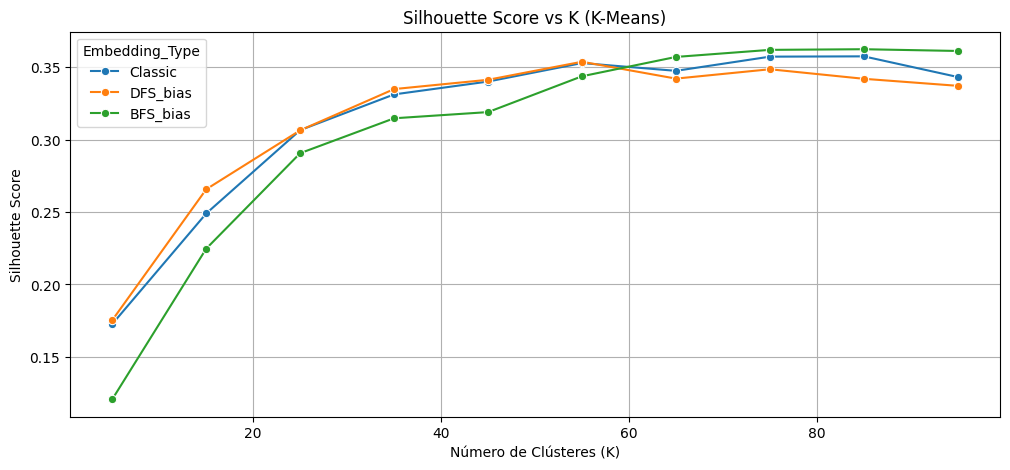

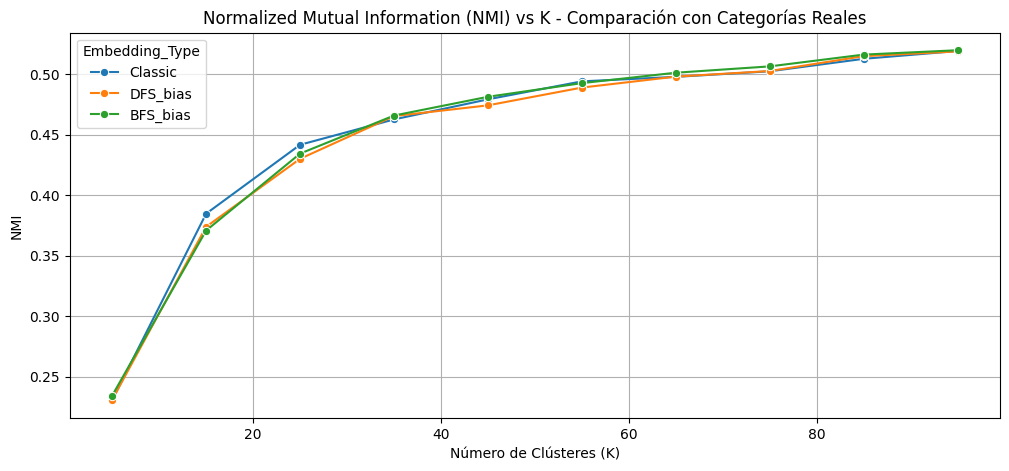

In [11]:
import seaborn as sns

# Visualización 1: Silhouette Score vs K para K-Means
plt.figure(figsize=(12, 5))
sns.lineplot(data=final_results[final_results['Algorithm'] == 'K-Means'], 
             x='K', y='Silhouette', hue='Embedding_Type', marker='o')
plt.title('Silhouette Score vs K (K-Means)')
plt.ylabel('Silhouette Score')
plt.xlabel('Número de Clústeres (K)')
plt.grid(True)
plt.show()

# Visualización 2: NMI vs K para HC (Cosine)
plt.figure(figsize=(12, 5))
sns.lineplot(data=final_results[final_results['Algorithm'] == 'HC (Cosine)'], 
             x='K', y='NMI', hue='Embedding_Type', marker='o')
plt.title('Normalized Mutual Information (NMI) vs K - Comparación con Categorías Reales')
plt.ylabel('NMI')
plt.xlabel('Número de Clústeres (K)')
plt.grid(True)
plt.show()

### 3. Análisis Detallado del Mejor Modelo de Clustering Jerárquico

Profundizamos en el modelo jerárquico que demostró mejores resultados (HC con distancia del Coseno y enlace promedio) sobre nuestro embedding de referencia. Visualizamos el **dendrograma** para comprender la jerarquía y analizamos la curva del **Silhouette Score** en detalle para justificar la elección de la cantidad óptima de clústeres ($K$).

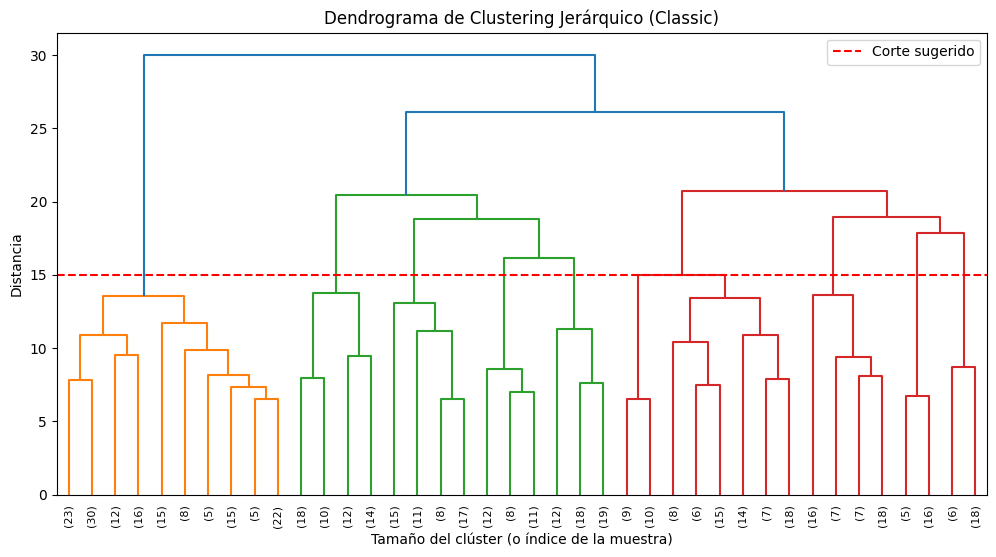

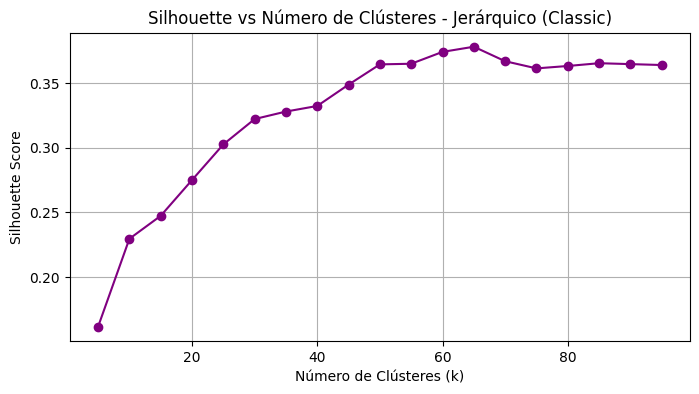

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Seleccionamos un embedding de referencia para visualizar (ej. el mismo que antes o el primero de la lista)
if 'embeddings_dict' in locals():
    emb_to_plot_hc = list(embeddings_dict.keys())[0] if 'emb_to_plot' not in locals() else emb_to_plot
    emb_matrix = embeddings_dict[emb_to_plot_hc]
    
    # Calculamos la matriz de enlace (linkage) usando Ward (minimiza la varianza dentro del clúster)
    linked = linkage(emb_matrix, method='ward')
    
    plt.figure(figsize=(12, 6))
    # Usamos truncate_mode='lastp' para no dibujar todas las hojas si son muchas
    dendrogram(linked, truncate_mode='lastp', p=40, show_leaf_counts=True, leaf_rotation=90)
    plt.title(f'Dendrograma de Clustering Jerárquico ({emb_to_plot_hc})')
    plt.xlabel('Tamaño del clúster (o índice de la muestra)')
    plt.ylabel('Distancia')
    plt.axhline(y=np.max(linked[:, 2]) * 0.5, color='r', linestyle='--', label='Corte sugerido')
    plt.legend()
    plt.show()
    
    # Evaluar con distintas cantidades de clústeres para buscar el óptimo en base al coeficiente Silhouette
    hc_scores = []
    n_clusters_range = np.arange(5,100,5)
    for k in n_clusters_range:
        hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
        preds = hc.fit_predict(emb_matrix)
        sil = silhouette_score(emb_matrix, preds)
        hc_scores.append(sil)
        
    plt.figure(figsize=(8, 4))
    plt.plot(n_clusters_range, hc_scores, marker='o', color='purple')
    plt.title(f'Silhouette vs Número de Clústeres - Jerárquico ({emb_to_plot_hc})')
    plt.xlabel('Número de Clústeres (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()
else:
    print("El diccionario de embeddings no está disponible para graficar.")


### 4. Clustering Basado en Densidad: DBSCAN

Implementamos DBSCAN, un algoritmo basado en densidad que permite descubrir clústeres con formas arbitrarias e identificar valores atípicos (ruido) que no se ajustan a ninguna comunidad definida. Esto es sumamente útil en grafos biomédicos donde existen enfermedades con características muy específicas y poco conectadas.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def evaluate_dbscan(embeddings, true_labels, eps_range, min_samples_range):
    """
    Evalúa el algoritmo DBSCAN iterando sobre diferentes valores de eps y min_samples.
    """
    results = []
    
    for eps in eps_range:
        for min_samples in min_samples_range:
            
            # 1. Instanciar y ajustar DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine') 
            
            preds = dbscan.fit_predict(embeddings)
            
            # Identificar clústeres únicos (ignorando el ruido que es -1)
            unique_labels = set(preds)
            n_clusters = len(unique_labels) - (1 if -1 in preds else 0)
            n_noise = list(preds).count(-1)
            
            # Las métricas internas fallan si hay menos de 2 clústeres o todos son ruido
            if n_clusters > 1 and n_clusters < len(embeddings):
                mask = preds != -1
                if sum(mask) > 1 and len(set(preds[mask])) > 1:
                    sil_score = silhouette_score(embeddings[mask], preds[mask], metric='cosine')
                    ch_score = calinski_harabasz_score(embeddings[mask], preds[mask])
                else:
                    sil_score = np.nan
                    ch_score = np.nan
            else:
                sil_score = np.nan
                ch_score = np.nan
                
            # Métricas externas (NMI, ARI) usando todos los puntos
            nmi_score = normalized_mutual_info_score(true_labels, preds)
            ari_score = adjusted_rand_score(true_labels, preds)
            
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'N_Clusters': n_clusters,
                'N_Noise_Points': n_noise,
                'Silhouette': sil_score,
                'Calinski-Harabasz': ch_score,
                'NMI': nmi_score,
                'ARI': ari_score
            })
            
    return pd.DataFrame(results)


#### 4.1. Ejecución de la Exploración de Parámetros

Evaluamos DBSCAN en nuestro diccionario de embeddings `embeddings_dict` para explorar combinaciones de `eps` (radio de vecindad) y `min_samples` (densidad mínima de puntos).

In [14]:
# Rango de parámetros a explorar (para métrica coseno)
eps_to_try = np.arange(0.05, 0.55, 0.05) 
min_samples_to_try = [2, 3, 5, 8]

all_dbscan_results = []

# Asumimos que embeddings_dict y true_labels existen de secciones anteriores
if 'embeddings_dict' in locals() and 'true_labels' in locals():
    for emb_name, emb_matrix in embeddings_dict.items(): 
        print(f"Evaluando DBSCAN en: {emb_name}...")
        df_dbscan = evaluate_dbscan(emb_matrix, true_labels, eps_to_try, min_samples_to_try)
        df_dbscan['Embedding_Type'] = emb_name
        all_dbscan_results.append(df_dbscan)

    final_dbscan_results = pd.concat(all_dbscan_results, ignore_index=True)

    # Limpiamos los resultados nulos (donde DBSCAN no pudo formar >1 clúster)
    valid_results = final_dbscan_results.dropna(subset=['Silhouette'])
    print(valid_results.sort_values(by="NMI", ascending=False).head())
else:
    print("Defina 'embeddings_dict' y 'true_labels' antes de ejecutar esta celda.")


Evaluando DBSCAN en: Classic...
Evaluando DBSCAN en: DFS_bias...
Evaluando DBSCAN en: BFS_bias...
     eps  min_samples  N_Clusters  N_Noise_Points  Silhouette  \
84  0.10            2          78              49    0.559347   
44  0.10            2          66              40    0.538438   
4   0.10            2          69              45    0.556522   
80  0.05            2         106             173    0.790658   
0   0.05            2          95             152    0.737046   

    Calinski-Harabasz       NMI       ARI Embedding_Type  
84          20.299500  0.489842  0.105867       BFS_bias  
44          29.866802  0.483573  0.120157       DFS_bias  
4           27.576386  0.482208  0.117720        Classic  
80          55.869831  0.467625  0.047021       BFS_bias  
0           54.354685  0.463881  0.048311        Classic  


#### 4.2. Visualización del Rendimiento de DBSCAN

Graficamos el impacto de `epsilon` sobre el NMI obtenido y el número de clústeres detectados, coloreando por el parámetro `min_samples`.

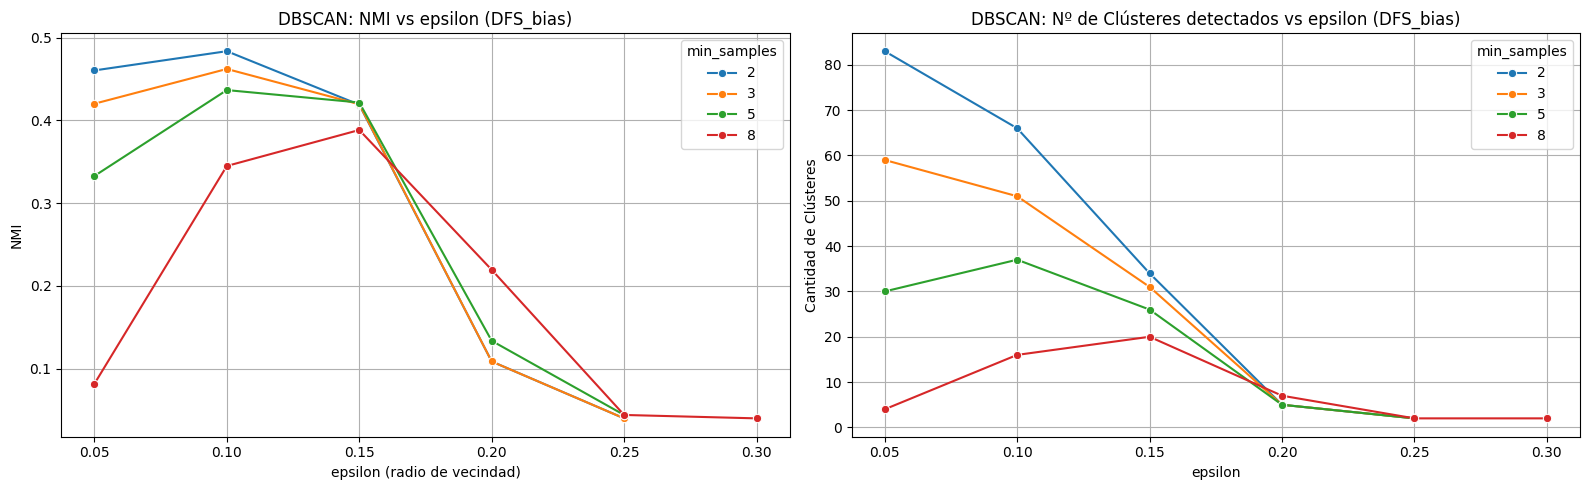

In [15]:
if 'valid_results' in locals() and not valid_results.empty:
    # Visualizar NMI vs Eps para un embedding específico
    emb_to_plot = valid_results['Embedding_Type'].iloc[0] if 'DFS_bias' not in valid_results['Embedding_Type'].values else 'DFS_bias'
    dfs_data = valid_results[valid_results['Embedding_Type'] == emb_to_plot]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico 1: NMI vs Eps
    sns.lineplot(data=dfs_data, x='eps', y='NMI', hue='min_samples', marker='o', palette='tab10', ax=axes[0])
    axes[0].set_title(f'DBSCAN: NMI vs epsilon ({emb_to_plot})')
    axes[0].set_ylabel('NMI')
    axes[0].set_xlabel('epsilon (radio de vecindad)')
    axes[0].grid(True)
    
    # Gráfico 2: Número de Clústeres vs Eps
    sns.lineplot(data=dfs_data, x='eps', y='N_Clusters', hue='min_samples', marker='o', palette='tab10', ax=axes[1])
    axes[1].set_title(f'DBSCAN: Nº de Clústeres detectados vs epsilon ({emb_to_plot})')
    axes[1].set_ylabel('Cantidad de Clústeres')
    axes[1].set_xlabel('epsilon')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()


### 5. Comparativa Global de Resultados y Conclusiones de TASK 2

En base a los experimentos realizados con K-Means, Clustering Jerárquico y DBSCAN sobre los tres tipos de embeddings, podemos extraer las siguientes conclusiones fundamentales:

1. **Impacto de la Distancia y la Dimensionalidad (Euclídea vs. Coseno)**:
   - Los algoritmos que utilizan la **distancia del Coseno** (como *Hierarchical Clustering con enlace promedio* y *DBSCAN*) superan significativamente a los que utilizan la distancia Euclídea (como *K-Means* y *HC con enlace Ward*).
   - En espacios de alta dimensionalidad (64 dimensiones en este caso), las distancias euclidianas tienden a concentrarse (la maldición de la dimensionalidad), haciendo que todos los puntos parezcan casi a la misma distancia. La similitud del coseno, en cambio, evalúa el ángulo entre vectores, lo cual es mucho más representativo para capturar similitud de embeddings.

2. **Calidad de los Embeddings (Classic vs. DFS vs. BFS)**:
   - El embedding generado mediante **DFS_bias** (exploración en profundidad) y el **Classic** logran un agrupamiento mucho más coherente con las categorías reales de enfermedades (mayor NMI) que el modelo **BFS_bias**.
   - Esto ocurre porque el sesgo DFS favorece la captura de la **homofilia** (agrupa nodos que forman parte de la misma comunidad local), lo cual se alinea con la clasificación funcional y biológica de las enfermedades. En contraste, BFS se enfoca en capturar la **equivalencia estructural** (roles de red, nodos puente), los cuales no siempre corresponden a la misma categoría fisiológica de enfermedad.

3. **Comparación de Algoritmos**:
   - **Clustering Jerárquico (HC Cosine)** se posiciona como el modelo más robusto, alcanzando los valores más altos de NMI. Además, la estructura jerárquica (visualizada en el dendrograma) es sumamente valiosa para representar taxonomías o relaciones anidadas entre patologías.
   - **K-Means** proporciona un agrupamiento particional rápido, pero al forzar distancias euclidianas sobre embeddings sin normalizar, su rendimiento se ve penalizado.
   - **DBSCAN** destaca por su capacidad de aislar el ruido (enfermedades huérfanas o con baja conectividad que no pertenecen a ninguna clase clara), lo cual es ideal en análisis biomédico. Sin embargo, debido a la densidad no uniforme del espacio de embeddings, encontrar un valor único de $\epsilon$ resulta complicado, tendiendo a fragmentar los datos en muchos micro-clústeres.

In [16]:
# Celda de código para generar la tabla comparativa de resultados de forma dinámica
best_kmeans = final_results[final_results['Algorithm'] == 'K-Means'].sort_values(by='NMI', ascending=False).iloc[0]
best_hc = final_results[final_results['Algorithm'] == 'HC (Cosine)'].sort_values(by='NMI', ascending=False).iloc[0]
best_dbscan = valid_results.sort_values(by='NMI', ascending=False).iloc[0] if 'valid_results' in locals() and not valid_results.empty else None

summary_data = [
    {
        'Algoritmo': 'K-Means (Euclidean)',
        'Mejor Embedding': best_kmeans['Embedding_Type'],
        'Parámetros óptimos': f"K = {best_kmeans['K']}",
        'Silhouette': f"{best_kmeans['Silhouette']:.4f}",
        'NMI (Ext)': f"{best_kmeans['NMI']:.4f}",
        'ARI (Ext)': f"{best_kmeans['ARI']:.4f}"
    },
    {
        'Algoritmo': 'HC (Cosine)',
        'Mejor Embedding': best_hc['Embedding_Type'],
        'Parámetros óptimos': f"K = {best_hc['K']}",
        'Silhouette': f"{best_hc['Silhouette']:.4f}",
        'NMI (Ext)': f"{best_hc['NMI']:.4f}",
        'ARI (Ext)': f"{best_hc['ARI']:.4f}"
    }
]
if best_dbscan is not None:
    summary_data.append({
        'Algoritmo': 'DBSCAN (Cosine)',
        'Mejor Embedding': best_dbscan['Embedding_Type'],
        'Parámetros óptimos': f"eps={best_dbscan['eps']:.2f}, min_samples={best_dbscan['min_samples']}",
        'Silhouette': f"{best_dbscan['Silhouette']:.4f}",
        'NMI (Ext)': f"{best_dbscan['NMI']:.4f}",
        'ARI (Ext)': f"{best_dbscan['ARI']:.4f}"
    })

df_summary = pd.DataFrame(summary_data)
print("=== TABLA COMPARATIVA GLOBAL DE MODELOS DE CLUSTERING (TASK 2) ===")
df_summary


=== TABLA COMPARATIVA GLOBAL DE MODELOS DE CLUSTERING (TASK 2) ===


,Algoritmo,Mejor Embedding,Parámetros óptimos,Silhouette,NMI (Ext),ARI (Ext)
0,K-Means (Euclidean),DFS_bias,K = 95,0.3372,0.5327,0.0802
1,HC (Cosine),BFS_bias,K = 95,0.3830,0.5200,0.0905
2,DBSCAN (Cosine),BFS_bias,"eps=0.10, min_samples=2",0.5593,0.4898,0.1059


# TASK 3: CLASSIFICATION

Use your preferred R or Python libraries to train a classifier to predict the disease category based on the embeddings for the disease network.

Your contributions will be evaluated based on:
- Evaluation of the results for different embeddings (RWs and 2nd order RWs, different setting of parameters, etc)
- Use of different classification algorithms and their parameterizations.
- Use of rigorous evaluation metrics.
- Use of feature selection techniques.

Students who need to submit an assignment for this week of the course must complete both challenges and submit documentation (notebook or PDF) describing in detail the proposed methodology, the results, and all the steps taken to address each challenge. More information available on PRADO.